In [2]:
import numpy as np

# Define function to draw 10000 samples from a Gaussian distribution with mean mu and standard deviation sigma
def draw_samples(mu, sigma, n_samples=10000):
    return np.random.normal(loc=mu, scale=sigma, size=n_samples)

toy_dist1 = draw_samples(0, 1)
toy_dist2 = draw_samples(0.9, 1.1)
toy_dist3 = draw_samples(1.1, 0.5)

# Save as .txt files
np.savetxt("toy_dist1.txt", toy_dist1)
np.savetxt("toy_dist2.txt", toy_dist2)
np.savetxt("toy_dist3.txt", toy_dist3)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# # Model definitions
# MODELS = {
#     "ST_PST19": dict(file="datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
#     "ST_PDT":   dict(file="datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra23: ST+PDT"),
#     "ST_PST":   dict(file="datafiles/ST_PST",   color="tab:orange", label="Vinciguerra23: ST+PST"),
#     "PDT_U":    dict(file="datafiles/PDT_U",    color="tab:green",  label="Vinciguerra23: PDT--U"),
#     "ST_U":     dict(file="datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra23: ST--U"),
#     "2spot":    dict(file="datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
#     "3spot":    dict(file="datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
# }

# Toy model definitions
MODELS = {
    "Model 1": dict(file="toy_dist1.txt", color="tab:pink",   label="Model 1"),
    "Model 2": dict(file="toy_dist2.txt", color="tab:blue",   label="Model 2"),
    "Model 3": dict(file="toy_dist3.txt", color="tab:orange", label="Model 3"),
}

# constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
c = 2.99792458e8      # m s^-1
M_sun = 1.98847e30    # kg

# Load Data and compute compactness
compactness = {}
KDEs_1D = {}
C_med = {}
C_lo = {}
C_hi = {}
S_i = {}
# for key, meta in MODELS.items():
#     filename = meta["file"]

#     data = np.loadtxt(filename)
#     M, R = data.T[0], data.T[1]

#     # Unit conversions
#     M_si = M * M_sun     # solar masses → kg
#     R_si = R * 1e3       # km → m

#     # Compactness C = GM / (Rc^2)
#     C = G * M_si / (R_si * c**2)
#     compactness[key] = C

#     # Summary statistics
#     C_med[key] = np.median(C)
#     C_lo[key] = np.min(C)
#     C_hi[key] = np.max(C)
#     S_i[key] = max(C_hi[key]- C_med[key], C_med[key]- C_lo[key])

#     print(
#         rf"{meta['label']}: "
#         rf"${C_med[key]:.4f}^{{+{C_hi[key]:.4f}}}_{{-{C_lo[key]:.4f}}}$"
#     )

#     # KDE
#     KDEs_1D[key] = gaussian_kde(C, bw_method="silverman")

for key, meta in MODELS.items(): # Toy version
    filename = meta["file"]

    data = np.loadtxt(filename)
    C = data
    compactness[key] = C

    # Summary statistics
    C_med[key] = np.median(C)
    C_lo[key] = np.min(C)
    C_hi[key] = np.max(C)
    S_i[key] = max(C_hi[key]- C_med[key], C_med[key]- C_lo[key])
    
    #Min and max of all models
    C_min = min(C_lo.values())
    C_max = max(C_hi.values())

    print(
        rf"{meta['label']}: "
        rf"${C_med[key]:.4f}^{{+{C_hi[key]:.4f}}}_{{-{C_lo[key]:.4f}}}$"
    )

    # KDE
    KDEs_1D[key] = gaussian_kde(C, bw_method="silverman")

# ------------------------------------------------------------
# Evaluate KDEs on common grid
# ------------------------------------------------------------
C_grid = np.linspace(C_min, C_max, 200)
dC = C_grid[1] - C_grid[0]

KDE_grid_values = {}
for key, kde in KDEs_1D.items():
    pdf = kde.evaluate(C_grid)
    KDE_grid_values[key] = pdf / np.trapz(pdf, C_grid)  # normalize

Model 1: $-0.0212^{+4.0902}_{--3.8455}$
Model 2: $0.8883^{+5.6774}_{--2.9431}$
Model 3: $1.1018^{+3.1131}_{--0.8257}$


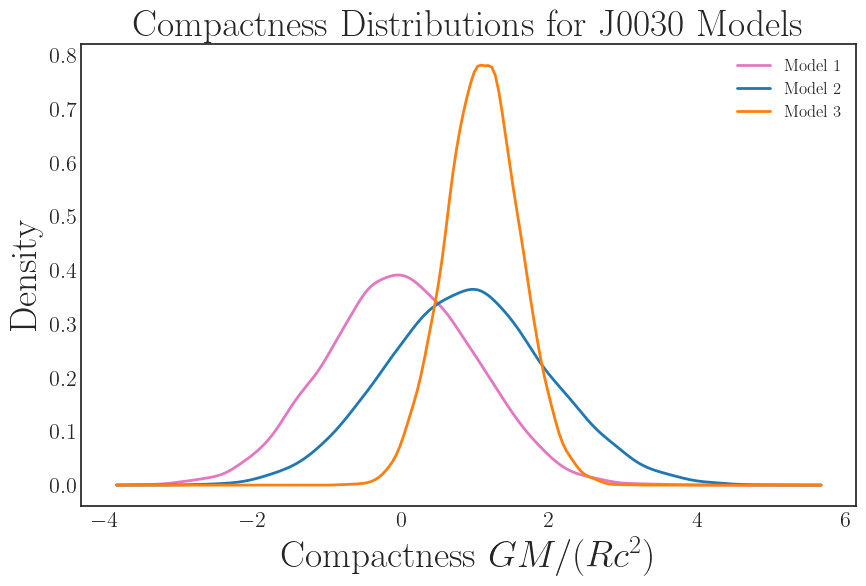

In [4]:
# Plot
plt.style.use("seaborn-v0_8-white")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

fig, ax = plt.subplots(figsize=(10, 6))

for key, meta in MODELS.items():
    ax.plot(
        C_grid,
        KDE_grid_values[key],
        color=meta["color"],
        lw=2,
        label=meta["label"]
    )

ax.set_xlabel("Compactness $GM/(Rc^2)$", fontsize=27)
ax.set_ylabel("Density", fontsize=27)
ax.set_title("Compactness Distributions for J0030 Models", fontsize=27)

ax.tick_params(labelsize=16)
ax.legend(fontsize=12)

fig.savefig(
    "/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/KDECompactnessVariousModels.png",
    dpi=300
)

# plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm

# ---------------------------------------------------
# SETTINGS
# ---------------------------------------------------

sigma_grid = np.logspace(-4, -0.5, 40)

# Jeffreys prior on sigma_shift
prior_sigma = 1.0 / sigma_grid
prior_sigma /= np.trapz(prior_sigma, sigma_grid)

# Mixture parameter grid (uniform prior)
p_grid = np.linspace(0, 1, 80)

# Dataset-specific bad widths S_i
S_i = {}
for key in MODELS:
    S_i[key] = max(C_hi[key] - C_med[key],
                   C_med[key] - C_lo[key])

dC = C_grid[1] - C_grid[0]

P_C_given_sigma = []
evidence_sigma = []

# ---------------------------------------------------
# MAIN HIERARCHICAL LOOP
# ---------------------------------------------------

for k, sigma in enumerate(sigma_grid):

    # Shifted likelihoods for this sigma
    shifted_likelihoods = {}

    for key in MODELS:
        L_i = KDEs_1D[key].evaluate(C_grid)
        sigma_pixels = sigma / dC
        L_i_shifted = gaussian_filter1d(L_i, sigma_pixels)
        shifted_likelihoods[key] = L_i_shifted

    # Build P(C | sigma) by marginalizing over p
    P_C_sigma = np.zeros_like(C_grid)

    for p in p_grid:

        product_likelihood = np.ones_like(C_grid)

        for key in MODELS:

            f_good = shifted_likelihoods[key]
            f_bad = norm.pdf(C_grid,
                             loc=C_med[key],
                             scale=S_i[key])

            mixture = p * f_good + (1 - p) * f_bad
            product_likelihood *= mixture

        P_C_sigma += product_likelihood

    # Uniform prior on p → average over grid
    P_C_sigma /= len(p_grid)

    # Evidence for this sigma
    Z_sigma = np.trapz(P_C_sigma, C_grid)
    evidence_sigma.append(Z_sigma)

    # Store normalized P(C | sigma)
    P_C_given_sigma.append(P_C_sigma / Z_sigma)

P_C_given_sigma = np.array(P_C_given_sigma)
evidence_sigma = np.array(evidence_sigma)

# ---------------------------------------------------
# POSTERIOR OVER sigma_shift
# ---------------------------------------------------

posterior_sigma = evidence_sigma * prior_sigma
posterior_sigma /= np.trapz(posterior_sigma, sigma_grid)

# ---------------------------------------------------
# FINAL POSTERIOR OVER C
# ---------------------------------------------------

final_posterior = np.zeros_like(C_grid)

for k in range(len(sigma_grid)):
    final_posterior += P_C_given_sigma[k] * posterior_sigma[k]

final_posterior /= np.trapz(final_posterior, C_grid)

# ---------------------------------------------------
# SUMMARY STATISTICS
# ---------------------------------------------------

cdf = np.cumsum(final_posterior) * dC
quantiles = [0.16, 0.50, 0.84]
quantile_values = np.interp(quantiles, cdf, C_grid)

print("Final marginalized compactness constraints:")
for q, val in zip(quantiles, quantile_values):
    print(f"{int(q*100)}%: {val:.4f}")

# sigma summary
d_sigma = sigma_grid[1] - sigma_grid[0]
cdf_sigma = np.cumsum(posterior_sigma) * d_sigma
sigma_quantiles = np.interp([0.16, 0.50, 0.84],
                            cdf_sigma,
                            sigma_grid)

print("\nInferred sigma_shift:")
print(f"Median: {sigma_quantiles[1]:.5f}")
print(f"68% interval: "
      f"[{sigma_quantiles[0]:.5f}, {sigma_quantiles[2]:.5f}]")

Final marginalized compactness constraints:
16%: 0.2936
50%: 0.8483
84%: 1.3383

Inferred sigma_shift:
Median: 0.31623
68% interval: [0.31623, 0.31623]


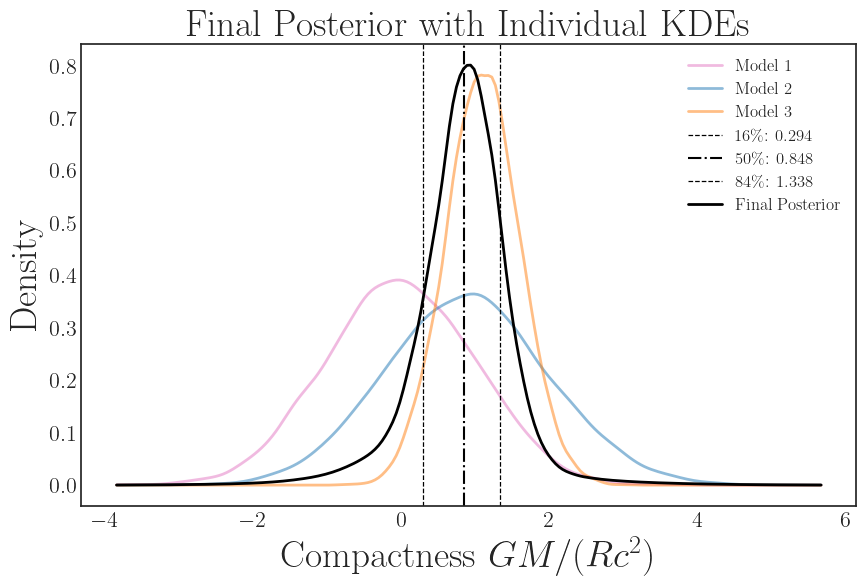

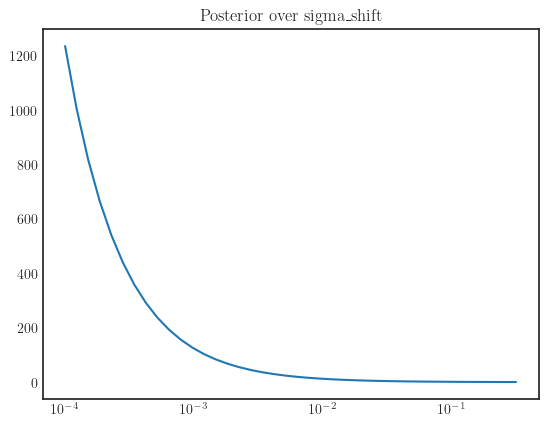

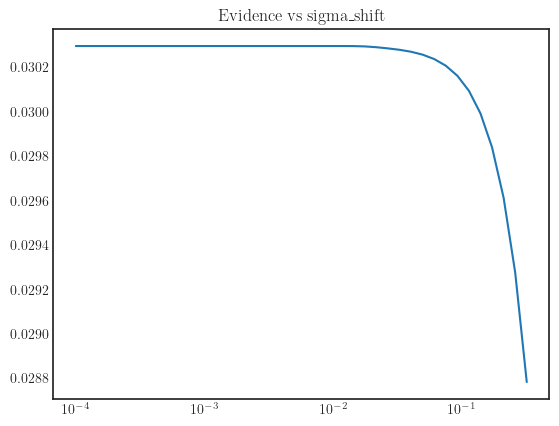

In [6]:
# Plot final posterior with individual measurements 
plt.style.use("seaborn-v0_8-white")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
fig, ax = plt.subplots(figsize=(10, 6))
for key, meta in MODELS.items():
    ax.plot(
        C_grid,
        KDE_grid_values[key],
        color=meta["color"],
        lw=2,
        alpha=0.5,
        label=meta["label"]
    )
    
# 16-50-84 markers
for q, val in zip(quantiles, quantile_values):
    style = "-." if q == 0.5 else "--"
    lw = 1.5 if q == 0.5 else 0.9
    ax.axvline(
        val,
        linestyle=style,
        color="black",
        linewidth=lw,
        label=rf"{int(q*100)}\%: {val:.3f}"
    )

ax.plot(C_grid, final_posterior, color="black", lw=2, alpha=1,label="Final Posterior")
ax.set_xlabel("Compactness $GM/(Rc^2)$", fontsize=27)
ax.set_ylabel("Density", fontsize=27)
ax.set_title("Final Posterior with Individual KDEs", fontsize=27)
ax.tick_params(labelsize=16)
ax.legend(fontsize=12)
plt.show()

plt.plot(sigma_grid, posterior_sigma)
plt.xscale("log")
plt.title("Posterior over sigma_shift")
plt.show()

plt.plot(sigma_grid, evidence_sigma)
plt.xscale("log")
plt.title("Evidence vs sigma_shift")
plt.show()

In [ ]:
# Shift only

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---------------------------------------------------
# SETTINGS
# ---------------------------------------------------

# Grid over compactness (already defined in your code)
# C_grid

# Log-uniform grid for sigma_shift (global hyperparameter)
sigma_grid = np.logspace(-4, 0, 60)

# Prior P(sigma) ∝ 1/sigma  (Jeffreys prior)
prior_sigma = 1.0 / sigma_grid
prior_sigma /= np.trapz(prior_sigma, sigma_grid)

# Storage
P_C_given_sigma = []
evidence_sigma = []

dC = C_grid[1] - C_grid[0]

# Shift-based method

for sigma in sigma_grid:

    product_likelihood = np.ones_like(C_grid)

    for key in MODELS:

        # Original KDE evaluated on grid
        L_i = KDEs_1D[key].evaluate(C_grid)

        # Convolution with Gaussian shift prior
        # Convert sigma_shift to grid units
        sigma_pixels = sigma / dC
        L_i_shifted = gaussian_filter1d(L_i, sigma_pixels)

        product_likelihood *= L_i_shifted

    # Evidence for this sigma
    Z_sigma = np.trapz(product_likelihood, C_grid)
    evidence_sigma.append(Z_sigma)

    # Store normalized P(C | sigma)
    P_C_given_sigma.append(product_likelihood / Z_sigma)

P_C_given_sigma = np.array(P_C_given_sigma)
evidence_sigma = np.array(evidence_sigma)

# ---------------------------------------------------
# POSTERIOR OVER sigma_shift
# ---------------------------------------------------

posterior_sigma = evidence_sigma * prior_sigma
posterior_sigma /= np.trapz(posterior_sigma, sigma_grid)

final_posterior = np.zeros_like(C_grid)

for k in range(len(sigma_grid)):
    final_posterior += P_C_given_sigma[k] * posterior_sigma[k]

final_posterior /= np.trapz(final_posterior, C_grid)

# ---------------------------------------------------
# Compute summary statistics
# ---------------------------------------------------

cdf = np.cumsum(final_posterior) * dC
quantiles = [0.16, 0.50, 0.84]
quantile_values = np.interp(quantiles, cdf, C_grid)

print("Final marginalized compactness constraints:")
for q, val in zip(quantiles, quantile_values):  
    print(f"{int(q*100)}%: {val:.4f}")

# Also report sigma_shift posterior summary
cdf_sigma = np.cumsum(posterior_sigma) * (sigma_grid[1] - sigma_grid[0])
sigma_quantiles = np.interp([0.16, 0.50, 0.84], cdf_sigma, sigma_grid)

print("\nInferred sigma_shift:")
print(f"Median: {sigma_quantiles[1]:.5f}")
print(f"68% interval: [{sigma_quantiles[0]:.5f}, {sigma_quantiles[2]:.5f}]")

# ---------------------------------------------------
# Plot results
# ---------------------------------------------------

plt.figure(figsize=(10,6))
plt.plot(C_grid, final_posterior / np.max(final_posterior),
         color='black', linewidth=2.5,
         label='Shift-marginalized Posterior')

for q, val in zip(quantiles, quantile_values):
    style = '-.' if q == 0.5 else '--'
    plt.axvline(val, linestyle=style, color='black', linewidth=1.2)

plt.xlabel(r"Compactness $GM/(Rc^2)$", fontsize=20)
plt.ylabel("P / Pmax", fontsize=20)
plt.title("Compactness with Hierarchical Shift Marginalization", fontsize=20)
plt.legend()
plt.show()

# Plot posterior over sigma_shift
plt.figure(figsize=(8,5))
plt.plot(sigma_grid, posterior_sigma, color='darkred', linewidth=2)
plt.xscale('log')
plt.xlabel(r"$\sigma_{\mathrm{shift}}$", fontsize=18)
plt.ylabel(r"$P(\sigma_{\mathrm{shift}}|\mathrm{data})$", fontsize=18)
plt.title("Posterior on Global Shift Scale", fontsize=18)
plt.show()